## Naseem Saleh
## INST414
## Module 4 Assignment¶
## November 7, 2025

dataset source:
https://www.kaggle.com/datasets/ishikajohari/best-books-10k-multi-genre-data?resource=download

Question - What genres are often clustered together with one genre for a book?


In [2]:
import pandas as pd

from sklearn.metrics import DistanceMetric, pairwise_distances

import matplotlib.pyplot as plt

import numpy as py

from sklearn.cluster import AgglomerativeClustering

from sklearn.preprocessing import MultiLabelBinarizer

In [52]:
books_df = pd.read_csv("goodreads_data.csv").fillna("Unknown")

In [53]:
books_df.head()

,Unnamed: 0,Book,Author,Description,Genres,Avg_Rating,Num_Ratings,URL
0,0,To Kill a Mockingbird,Harper Lee,The unforgettable novel of a childhood in a sl...,"['Classics', 'Fiction', 'Historical Fiction', ...",4.27,"5,691,311",https://www.goodreads.com/book/show/2657.To_Ki...
1,1,Harry Potter and the Philosopher’s Stone (Harr...,J.K. Rowling,Harry Potter thinks he is an ordinary boy - un...,"['Fantasy', 'Fiction', 'Young Adult', 'Magic',...",4.47,"9,278,135",https://www.goodreads.com/book/show/72193.Harr...
2,2,Pride and Prejudice,Jane Austen,"Since its immediate success in 1813, Pride and...","['Classics', 'Fiction', 'Romance', 'Historical...",4.28,"3,944,155",https://www.goodreads.com/book/show/1885.Pride...
3,3,The Diary of a Young Girl,Anne Frank,Discovered in the attic in which she spent the...,"['Classics', 'Nonfiction', 'History', 'Biograp...",4.18,"3,488,438",https://www.goodreads.com/book/show/48855.The_...
4,4,Animal Farm,George Orwell,Librarian's note: There is an Alternate Cover ...,"['Classics', 'Fiction', 'Dystopia', 'Fantasy',...",3.98,"3,575,172",https://www.goodreads.com/book/show/170448.Ani...


In [54]:
books_df["Genres"].unique()

array(["['Classics', 'Fiction', 'Historical Fiction', 'School', 'Literature', 'Young Adult', 'Historical']",
       "['Fantasy', 'Fiction', 'Young Adult', 'Magic', 'Childrens', 'Middle Grade', 'Classics']",
       "['Classics', 'Fiction', 'Romance', 'Historical Fiction', 'Literature', 'Historical', 'Audiobook']",
       ...,
       "['Dystopia', 'Science Fiction', 'Post Apocalyptic', 'Paranormal', 'Fantasy']",
       "['Fiction', 'Horror', 'Dystopia', 'Coming Of Age']",
       "['New Adult', 'Romance', 'Contemporary Romance', 'Contemporary']"],
      dtype=object)

In [55]:
books_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   10000 non-null  int64  
 1   Book         10000 non-null  object 
 2   Author       10000 non-null  object 
 3   Description  10000 non-null  object 
 4   Genres       10000 non-null  object 
 5   Avg_Rating   10000 non-null  float64
 6   Num_Ratings  10000 non-null  object 
 7   URL          10000 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 625.1+ KB


In [56]:
books_df["Genres"].value_counts()

Genres
[]                                                                                                            960
['Fiction']                                                                                                    49
['Fantasy']                                                                                                    42
['Nonfiction']                                                                                                 24
['Romance']                                                                                                    20
                                                                                                             ... 
['Historical Fiction', 'Historical']                                                                            1
['Humor', 'Fiction', 'Audiobook', 'German Literature', 'Comedy', 'Contemporary', 'Short Stories']               1
['Dystopia', 'Science Fiction', 'Post Apocalyptic', 'Paranormal', 'Fantasy']     

In [57]:
types_check = books_df["Genres"].map(type).value_counts()

print(types_check)

Genres
<class 'str'>    10000
Name: count, dtype: int64


In [58]:
import ast
#Converting to lists since look like lists but are strings
books_df["Genres"] = books_df["Genres"].apply(lambda col_val: ast.literal_eval(col_val))

types_check2 = books_df["Genres"].map(type).value_counts()

print(types_check2)

Genres
<class 'list'>    10000
Name: count, dtype: int64


In [59]:
#Finds empty lists and fill them with unknown.  if empty / x = false . not false returns true
books_df["Genres"] = books_df["Genres"].apply(lambda x: ["Unknown"] if isinstance(x, list) and not x else x)

In [60]:
books_df["Genres"].value_counts()

Genres
[Unknown]                                                                                       960
[Fiction]                                                                                        49
[Fantasy]                                                                                        42
[Nonfiction]                                                                                     24
[Romance]                                                                                        20
                                                                                               ... 
[Historical Fiction, Historical]                                                                  1
[Humor, Fiction, Audiobook, German Literature, Comedy, Contemporary, Short Stories]               1
[Dystopia, Science Fiction, Post Apocalyptic, Paranormal, Fantasy]                                1
[Fiction, Horror, Dystopia, Coming Of Age]                                                   

In [61]:
#books_df = books_df.reindex(sorted(books_df.columns), axis = 1)

In [132]:
#Dropping Unknown genre books . the value is a list
books_df = books_df[books_df["Genres"].apply(lambda x: x != ["Unknown"])]

books_df["Genres"].value_counts()

Genres
[Fiction]                                                                              49
[Fantasy]                                                                              42
[Nonfiction]                                                                           24
[Romance]                                                                              20
[Poetry]                                                                               18
                                                                                       ..
[Historical Fiction, Historical]                                                        1
[Humor, Fiction, Audiobook, German Literature, Comedy, Contemporary, Short Stories]     1
[Dystopia, Science Fiction, Post Apocalyptic, Paranormal, Fantasy]                      1
[Fiction, Horror, Dystopia, Coming Of Age]                                              1
[Classics, Fiction, School, Historical Fiction, Literature, Romance, Novels]            1
Nam

In [135]:
mlb = MultiLabelBinarizer()
#Binarizing for geting jaccard similarity:
binarized_g = mlb.fit_transform(books_df["Genres"])
genres_labels = mlb.classes_

genres_df = pd.DataFrame(binarized_g, columns = genres_labels)

In [136]:
#Filtering out rarer genres that only appear in 1 book:
less_genres = genres_df.columns[genres_df.sum() >= 5]
filt_genres_df = genres_df[less_genres]

filt_genres_df.head()

,16th Century,17th Century,18th Century,19th Century,20th Century,21st Century,Abuse,Action,Adoption,Adult,...,Womens Fiction,World History,World War I,World War II,Writing,Young Adult,Young Adult Contemporary,Young Adult Fantasy,Young Adult Romance,Zombies
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [240]:
from scipy.sparse import csr_matrix

#get sparse to ignore 0s so don't have too slow code / memory error
g_array = csr_matrix(np.transpose(filt_genres_df.values.astype(bool)))

g_num = g_array.shape[0] #0 = genre rows.  number of genres

genres = filt_genres_df.columns

#Initializes empty dataframe to put the jaccard similarities in
jaccard_df = pd.DataFrame(0.0, index=genres, columns=genres)

from sklearn.metrics import jaccard_score

#Loops over the pairs of genres
for gen1 in range(g_num):
    books2 = set(g_array[gen1].nonzero()[1])  #Get only the books with genre 1
    for gen2 in range(gen1, g_num):
    #for gen2 in range(gen1 + 1, g_num): #+1 so doesn't repeat same one
        books1 = set(g_array[gen2].nonzero()[1]) #Get only the books with genre 2

        #Gets the current row for both genres
        #gen1_row = g_array.getrow(gen1)
        #gen2_row = g_array.getrow(gen2)

        #Gets books where both genres exist
        #intersection = gen1_row.multiply(gen2_row).sum()

        intersection = len(books1 & books2)
        union = len(books1 | books2)
        
        #Gets where at least one exists
        #union = gen1_row + gen2_row  #can result in 2s , 3 etc.
        #union.data = np.ones_like(union.data) #Turns counts to 1 for union to be correct in similarity calc
        #union_sum = union.sum()

        #if union_sum
        if union > 0:
            jaccard = intersection / union
        else:
            jaccard = 0.0

        #Gets jaccard similarity
        genre_1, genre_2 = genres[gen1], genres[gen2]
        jaccard_df.loc[genre_1, genre_2] = jaccard
        jaccard_df.loc[genre_2, genre_1] = jaccard


#Gets the jaccard distance for clustering
distance_m = 1 - jaccard_df.values

print(jaccard_df.head())

              16th Century  17th Century  18th Century  19th Century  \
16th Century           1.0           0.0           0.0           0.0   
17th Century           0.0           1.0           0.0           0.0   
18th Century           0.0           0.0           1.0           0.0   
19th Century           0.0           0.0           0.0           1.0   
20th Century           0.0           0.0           0.0           0.0   

              20th Century  21st Century  Abuse  Action  Adoption     Adult  \
16th Century           0.0           0.0    0.0     0.0       0.0  0.001466   
17th Century           0.0           0.0    0.0     0.0       0.0  0.000000   
18th Century           0.0           0.0    0.0     0.0       0.0  0.000000   
19th Century           0.0           0.0    0.0     0.0       0.0  0.000000   
20th Century           1.0           0.0    0.0     0.0       0.0  0.000000   

              ...  Womens Fiction  World History  World War I  World War II  \
16th Century 

In [241]:
#Using AgglomerativeClustering to get the clusters . k -value automatic 
from sklearn.cluster import AgglomerativeClustering
clustering = AgglomerativeClustering(n_clusters = 20, metric = "precomputed", linkage = "average").fit(distance_m)
clustering
#AgglomerativeClustering()
labels = clustering.labels_
#array

In [242]:
#Views the clusters matched to the genres in the df
genre_clusters = pd.DataFrame({"Genre": jaccard_df.index, "Cluster": labels})
print(genre_clusters.sort_values("Cluster"))

                  Genre  Cluster
318  Spanish Literature        0
326         Superheroes        0
209     Magical Realism        0
211               Manga        0
244                Noir        0
..                  ...      ...
351             Ukraine       18
297     Russian History       18
298  Russian Literature       18
296              Russia       18
273         Prehistoric       19

[373 rows x 2 columns]


In [243]:
#Count how many in each cluster there is 
count_clusters = genre_clusters["Cluster"].value_counts().sort_index()

print(count_clusters)

Cluster
0      21
1      11
2      15
3     126
4      15
5     116
6      13
7       9
8       6
9       2
10      4
11      1
12      9
13      1
14     10
15      1
16      6
17      2
18      4
19      1
Name: count, dtype: int64


In [244]:
#Seeing some of the genres in each cluster
for c in sorted(genre_clusters['Cluster'].unique()):
    sample = genre_clusters[genre_clusters['Cluster'] == c]['Genre'].tolist()[:15]
    print(f"Cluster {c}: {sample} ... \n")

Cluster 0: ['Asia', 'Asian Literature', 'China', 'Comic Book', 'Comics', 'Cultural', 'Graphic Novels', 'Graphic Novels Comics', 'India', 'Indian Literature', 'Iran', 'Japan', 'Japanese Literature', 'Latin American', 'Latin American Literature'] ... 

Cluster 1: ['Africa', 'African Literature', 'Egypt', 'Finnish Literature', 'Islam', 'Nigeria', 'Poland', 'Polish Literature', 'South Africa', 'Sudan', 'Unfinished'] ... 

Cluster 2: ['Ancient', 'Ancient History', 'Canada', 'Canadian Literature', 'Dutch Literature', 'European History', 'Greece', 'Israel', 'Jewish', 'Judaism', 'Roman', 'Turkish', 'Turkish Literature', 'World History', 'World War I'] ... 

Cluster 3: ['17th Century', '19th Century', '20th Century', 'Abuse', 'Action', 'Adult', 'Adult Fiction', 'Adventure', 'Amazon', 'American', 'Amish', 'Angels', 'Apocalyptic', 'Arthurian', 'Audiobook'] ... 

Cluster 4: ['Aliens', 'Alternate History', 'Astronomy', 'Cyberpunk', 'Hugo Awards', 'Mathematics', 'Metaphysics', 'New Age', 'Occult', '

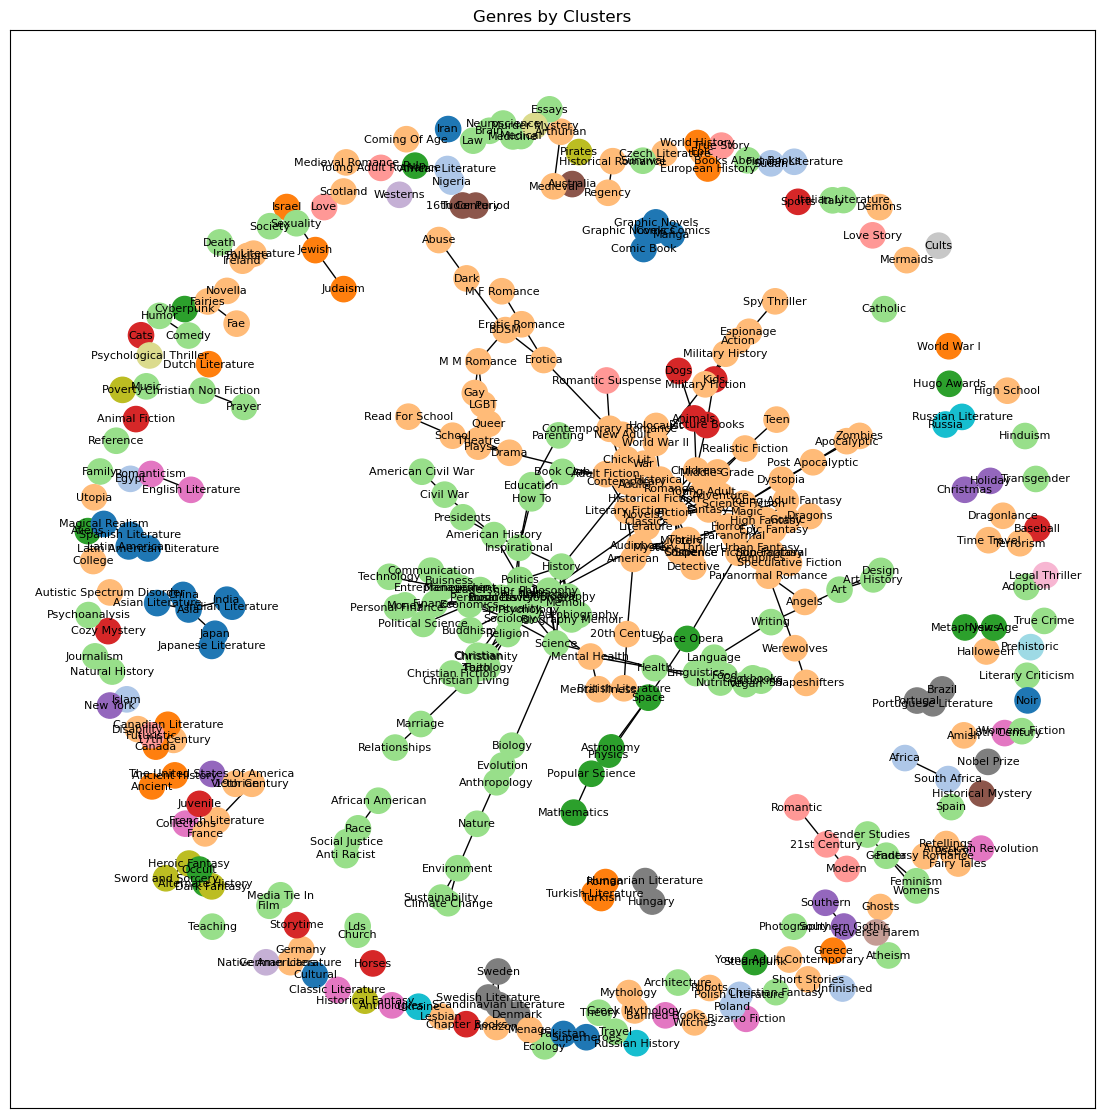

In [247]:
import networkx as nx
# Threshold for showing an edge
threshold = 0.1

# Initializes empty graph
G = nx.Graph()

# Adds nodes with cluster as attribute
for idx, row in genre_clusters.iterrows():
    G.add_node(row["Genre"], cluster=row["Cluster"])

# Adds edges based on Jaccard similarity
for i, genre1 in enumerate(jaccard_df.index):
    for j, genre2 in enumerate(jaccard_df.columns):
        if i < j:  #Avoiding repeated edges
            similarity = jaccard_df.iloc[i, j]
            if similarity > threshold:
                G.add_edge(genre1, genre2, weight = similarity)

# Draws the graph
plt.figure(figsize=(14, 14))

# Colors nodes by cluster
clusters = [G.nodes[n]["cluster"] for n in G.nodes()]
nx.draw_networkx(G, node_color = clusters, cmap = plt.cm.tab20, with_labels = True, node_size = 330, font_size = 8)

plt.title("Genres by Clusters")

plt.savefig("genre_clusters.png", dpi=300) 

plt.show()